# Lecture 22: Hamiltonian Actions

**Source span.** Printed pages 131-138; physical PDF pages 145-152 in `Lectures on Symplectic Geometry.pdf`.

**Chapter goal.** This lecture upgrades the one-parameter Hamiltonian story into the full moment-map language. A Hamiltonian `G`-space is a symplectic manifold with a group action and a map `mu: M -> g*` whose components generate the infinitesimal action and whose values transform by the coadjoint representation. The lecture then uses orbit spaces and the circle action on `C^n` to preview reduction, and closes with the classical linear/angular momentum examples and the coadjoint-orbit homework.

The notebook is built as a replacement for a generic scaffold. It preserves the useful course structure of a source span, artifact display, checks, and final sanity ledger, but the prose, figures, and code are now specific to this chapter. Each visual has a job: expose the definition, show where quotient topology can misbehave, make the reduction preview inspectable, compute classical momentum maps, or verify the Lie-Poisson/Kostant-Kirillov structure behind coadjoint orbits.

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import sympy as sp
from IPython.display import Image, display


def find_lsg_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "artifacts").is_dir():
            return candidate
    raise RuntimeError("Could not locate the LSG course root.")


BOOK_ROOT = find_lsg_root()
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / "lecture-22"
FIGURES = ARTIFACT_ROOT / "figures"
CHECKS = ARTIFACT_ROOT / "checks"
for target in (FIGURES, CHECKS):
    target.mkdir(parents=True, exist_ok=True)


def relpath(path: Path) -> str:
    return path.relative_to(BOOK_ROOT).as_posix()


def save_json(path: Path, payload: dict) -> None:
    path.write_text(json.dumps(payload, indent=2), encoding="utf-8")


def display_artifact(relative: str, *, width: int = 760) -> None:
    display(Image(filename=str(BOOK_ROOT / relative), width=width))


def show(relative: str, *, width: int = 760) -> None:
    display_artifact(relative, width=width)


source_span = {
    "lecture": 22,
    "title": "Hamiltonian Actions",
    "printed_pages": "131-138",
    "physical_pdf_pages": "145-152",
    "source_note": (
        "Inspected the local PDF text for moment/comoment maps, orbit spaces, "
        "the C^n reduction preview, SO(3) coadjoint orbits, linear and angular "
        "momentum, and the coadjoint-orbit homework."
    ),
}
save_json(CHECKS / "source-span.json", source_span)
source_span

{'lecture': 22,
 'title': 'Hamiltonian Actions',
 'printed_pages': '131-138',
 'physical_pdf_pages': '145-152',
 'source_note': 'Inspected the local PDF text for moment/comoment maps, orbit spaces, the C^n reduction preview, SO(3) coadjoint orbits, linear and angular momentum, and the coadjoint-orbit homework.'}

## Translation Guide

`Moment map` means a single map into `g*` whose scalar component in the direction `X in g` is a Hamiltonian for the vector field generated by the one-parameter subgroup `exp(tX)`. The first condition is local and differential: `d(mu^X)=i_{X#} omega`. The second condition is global and equivariant: moving the point by the group moves the covector by the coadjoint action.

`Comoment map` is the same information read backward as a map `g -> C^\infty(M)`. It sends `X` to the Hamiltonian function `mu^X`. The bracket condition says this assignment is compatible with the Lie algebra bracket and the Poisson bracket.

`Orbit space` means the quotient by the action. The lecture warns that quotient topology can be bad: the `R`-action on the line by positive scaling has three orbits and fails the Hausdorff separation test at the fixed orbit; the `C*`-action on `C^n` behaves well only after the unstable origin is removed.

`Reduction preview` means the first model of Marsden-Weinstein reduction: a circle acts on `C^n`, the moment map level `mu^{-1}(0)` can be chosen as the unit sphere, and the quotient `S^{2n-1}/S^1` is complex projective space.

`Classical examples` connect the abstract definition to mechanics: translation gives linear momentum, rotation gives angular momentum, and for `SO(3)` the coadjoint orbits are spheres carrying the Kostant-Kirillov symplectic form.

## Library Routing

Matplotlib handles the moment-map level diagrams, quotient sketches, and classical vector pictures because the geometry is visible in low-dimensional coordinates. NetworkX is used for the definition route since the moment/comoment conditions are a dependency structure. SymPy checks the Lie-Poisson bracket identities exactly. NumPy checks the symplectic contractions, quotient level values, cross products, spectra, and rank/kernel properties.

In [2]:
storyboard = {
    "chapter_goal": "Make Hamiltonian G-spaces, comoment maps, orbit spaces, reduction preview, classical momentum maps, and coadjoint orbits executable.",
    "source_span_read": source_span,
    "library_routing": [
        {
            "concept": "moment and comoment maps",
            "representation": "definition dependency graph plus exact Poisson bracket checks",
            "library": "NetworkX + SymPy",
            "why": "the two moment-map axioms and the comoment bracket axiom are structural dependencies",
            "fallback": "definition table",
        },
        {
            "concept": "orbit spaces",
            "representation": "quotient topology pathology diagrams",
            "library": "Matplotlib",
            "why": "bad orbit spaces are best seen as collapsed reachable sets with separation failures marked",
            "fallback": "orbit ledger",
        },
        {
            "concept": "preview of reduction",
            "representation": "C^n circle-action level-set panel",
            "library": "Matplotlib + NumPy",
            "why": "moment fibers, zero level, and half-space image are radial numerical objects",
            "fallback": "radius table",
        },
        {
            "concept": "linear and angular momentum",
            "representation": "position/momentum/cross-product vector diagram",
            "library": "Matplotlib 3D + NumPy",
            "why": "the maps y -> -y and (x,y) -> x cross y are vector-valued and spatial",
            "fallback": "component table",
        },
        {
            "concept": "coadjoint orbits and Lie-Poisson structure",
            "representation": "SO(3) coadjoint spheres plus KKS rank/kernel checks",
            "library": "Matplotlib 3D + SymPy + NumPy",
            "why": "the orbit is a sphere and the Poisson/KKS checks are exact algebra",
            "fallback": "rank ledger",
        },
    ],
    "visual_sequence": [
        {
            "concept": "Moment/comoment definition route",
            "artifact": relpath(FIGURES / "moment-comoment-definition-route.png"),
            "inspection_target": "follow the two moment-map axioms into the comoment bracket condition",
            "validation": "Poisson bracket for coordinate functions on so(3)* has zero Jacobiator",
        },
        {
            "concept": "Orbit-space topology warnings",
            "artifact": relpath(FIGURES / "orbit-space-quotient-pathologies.png"),
            "inspection_target": "see which orbits collapse and why the fixed/unstable point is hard to separate",
            "validation": "orbit ledgers distinguish Hausdorff and non-Hausdorff models",
        },
        {
            "concept": "Circle action reduction preview",
            "artifact": relpath(FIGURES / "circle-action-cn-reduction-preview.png"),
            "inspection_target": "connect radial moment map, zero level sphere, quotient, and half-space image",
            "validation": "unit sphere samples have mu=0 after choosing constant 1/2",
        },
        {
            "concept": "Classical linear and angular momentum",
            "artifact": relpath(FIGURES / "linear-angular-momentum-maps.png"),
            "inspection_target": "compare translation momentum with rotation angular momentum",
            "validation": "angular Hamiltonian contraction matches d<a, x cross y>",
        },
        {
            "concept": "SO(3) coadjoint orbit and KKS form",
            "artifact": relpath(FIGURES / "so3-coadjoint-orbit-kks-check.png"),
            "inspection_target": "read coadjoint spheres as symplectic leaves of the Lie-Poisson bracket",
            "validation": "KKS kernel is the stabilizer direction and tangent rank is two",
        },
    ],
}
save_json(CHECKS / "visual-storyboard.json", storyboard)
print("storyboard visuals:", len(storyboard["visual_sequence"]))

storyboard visuals: 5


## Moment And Comoment Maps

The first definition in the source has two checks. For every Lie algebra element `X`, the scalar function `mu^X(p)=<mu(p),X>` must generate the vector field `X#` through `d(mu^X)=i_{X#} omega`. Then `mu` must be equivariant for the original action on `M` and the coadjoint action on `g*`. The comoment form packages the same data as `mu*: g -> C^\infty(M)`, with the Poisson bracket mirroring the Lie bracket.

For `R`, `S^1`, and tori the coadjoint action is trivial, so equivariance becomes invariance. For nonabelian groups, especially `SO(3)`, the coadjoint action is real geometry: it rotates angular momentum vectors and its orbits are spheres.

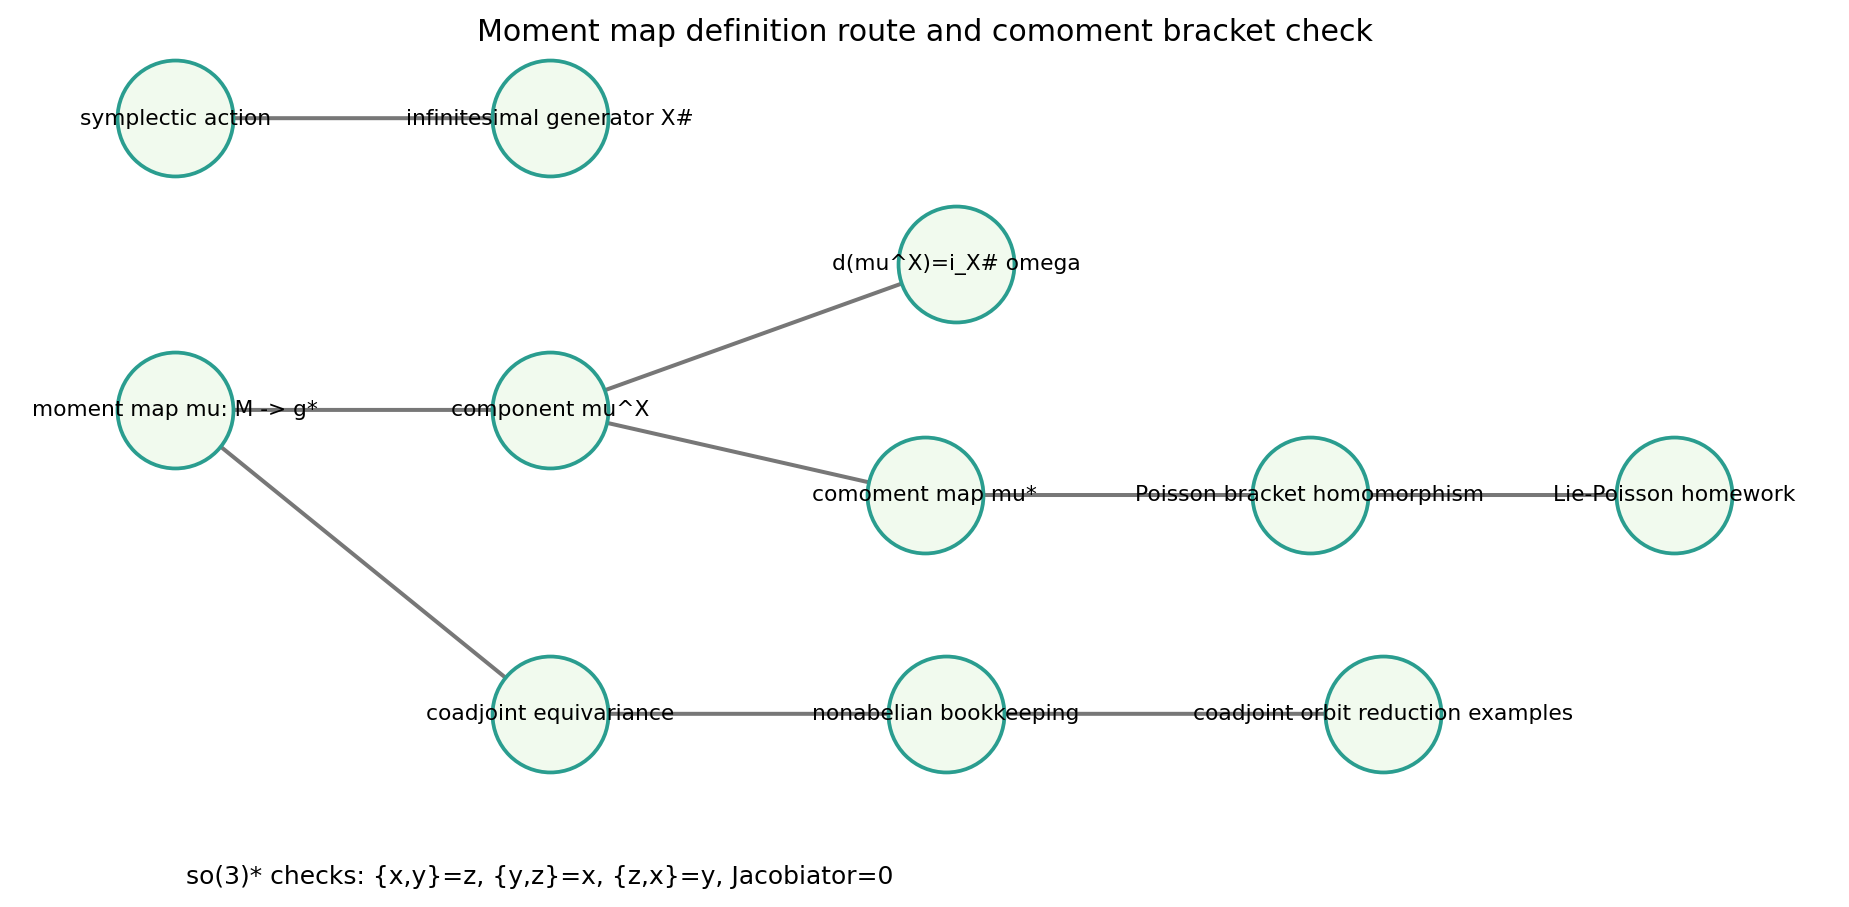

In [3]:
x, y, z = sp.symbols("x y z")


def lie_poisson(f, g):
    grad_f = sp.Matrix([sp.diff(f, x), sp.diff(f, y), sp.diff(f, z)])
    grad_g = sp.Matrix([sp.diff(g, x), sp.diff(g, y), sp.diff(g, z)])
    xi = sp.Matrix([x, y, z])
    return sp.expand(xi.dot(grad_f.cross(grad_g)))


bracket_xy = lie_poisson(x, y)
bracket_yz = lie_poisson(y, z)
bracket_zx = lie_poisson(z, x)
jacobiator = sp.expand(lie_poisson(bracket_xy, z) + lie_poisson(bracket_yz, x) + lie_poisson(bracket_zx, y))

route = nx.DiGraph()
route_edges = [
    ("symplectic action", "infinitesimal generator X#"),
    ("moment map mu: M -> g*", "component mu^X"),
    ("component mu^X", "d(mu^X)=i_X# omega"),
    ("moment map mu: M -> g*", "coadjoint equivariance"),
    ("coadjoint equivariance", "nonabelian bookkeeping"),
    ("component mu^X", "comoment map mu*"),
    ("comoment map mu*", "Poisson bracket homomorphism"),
    ("Poisson bracket homomorphism", "Lie-Poisson homework"),
    ("nonabelian bookkeeping", "coadjoint orbit reduction examples"),
]
route.add_edges_from(route_edges)
pos = {
    "symplectic action": (0, 1.8),
    "infinitesimal generator X#": (1.8, 1.8),
    "moment map mu: M -> g*": (0, 0.6),
    "component mu^X": (1.8, 0.6),
    "d(mu^X)=i_X# omega": (3.75, 1.2),
    "coadjoint equivariance": (1.8, -0.65),
    "nonabelian bookkeeping": (3.7, -0.65),
    "comoment map mu*": (3.6, 0.25),
    "Poisson bracket homomorphism": (5.45, 0.25),
    "Lie-Poisson homework": (7.2, 0.25),
    "coadjoint orbit reduction examples": (5.8, -0.65),
}
fig, ax = plt.subplots(figsize=(13, 5.2))
nx.draw_networkx_edges(route, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=16, width=1.6, edge_color="#777777")
nx.draw_networkx_nodes(route, pos, ax=ax, node_color="#f1faee", edgecolors="#2a9d8f", node_size=2150, linewidths=1.5)
nx.draw_networkx_labels(route, pos, ax=ax, font_size=8.7)
ax.text(0.05, -1.35, f"so(3)* checks: {{x,y}}={bracket_xy}, {{y,z}}={bracket_yz}, {{z,x}}={bracket_zx}, Jacobiator={jacobiator}", fontsize=10)
ax.set_title("Moment map definition route and comoment bracket check")
ax.set_axis_off()
definition_path = FIGURES / "moment-comoment-definition-route.png"
fig.savefig(definition_path, dpi=180, bbox_inches="tight")
plt.close(fig)

assert bracket_xy == z
assert bracket_yz == x
assert bracket_zx == y
assert jacobiator == 0
show(relpath(definition_path))

## Orbit Spaces Can Be Bad

The lecture pauses before reduction to remind us that quotients are not automatically manifolds. The action `t.x = e^t x` on the real line has three orbits: positive, negative, and the fixed point `0`. The quotient topology makes every saturated open neighborhood of the fixed orbit touch the positive and negative sides, so the fixed orbit is not cleanly separated from the others. Similarly, the `C*` action on `C^n` has the projective orbits of nonzero vectors plus one unstable origin; deleting the origin gives the familiar Hausdorff projective quotient.

This warning is why reduction theorems need regularity, freeness, and properness-style hypotheses. The pictures below are deliberately simple because the problem is not computation but topology: collapsing orbits can merge local information in ways no coordinate chart can repair.

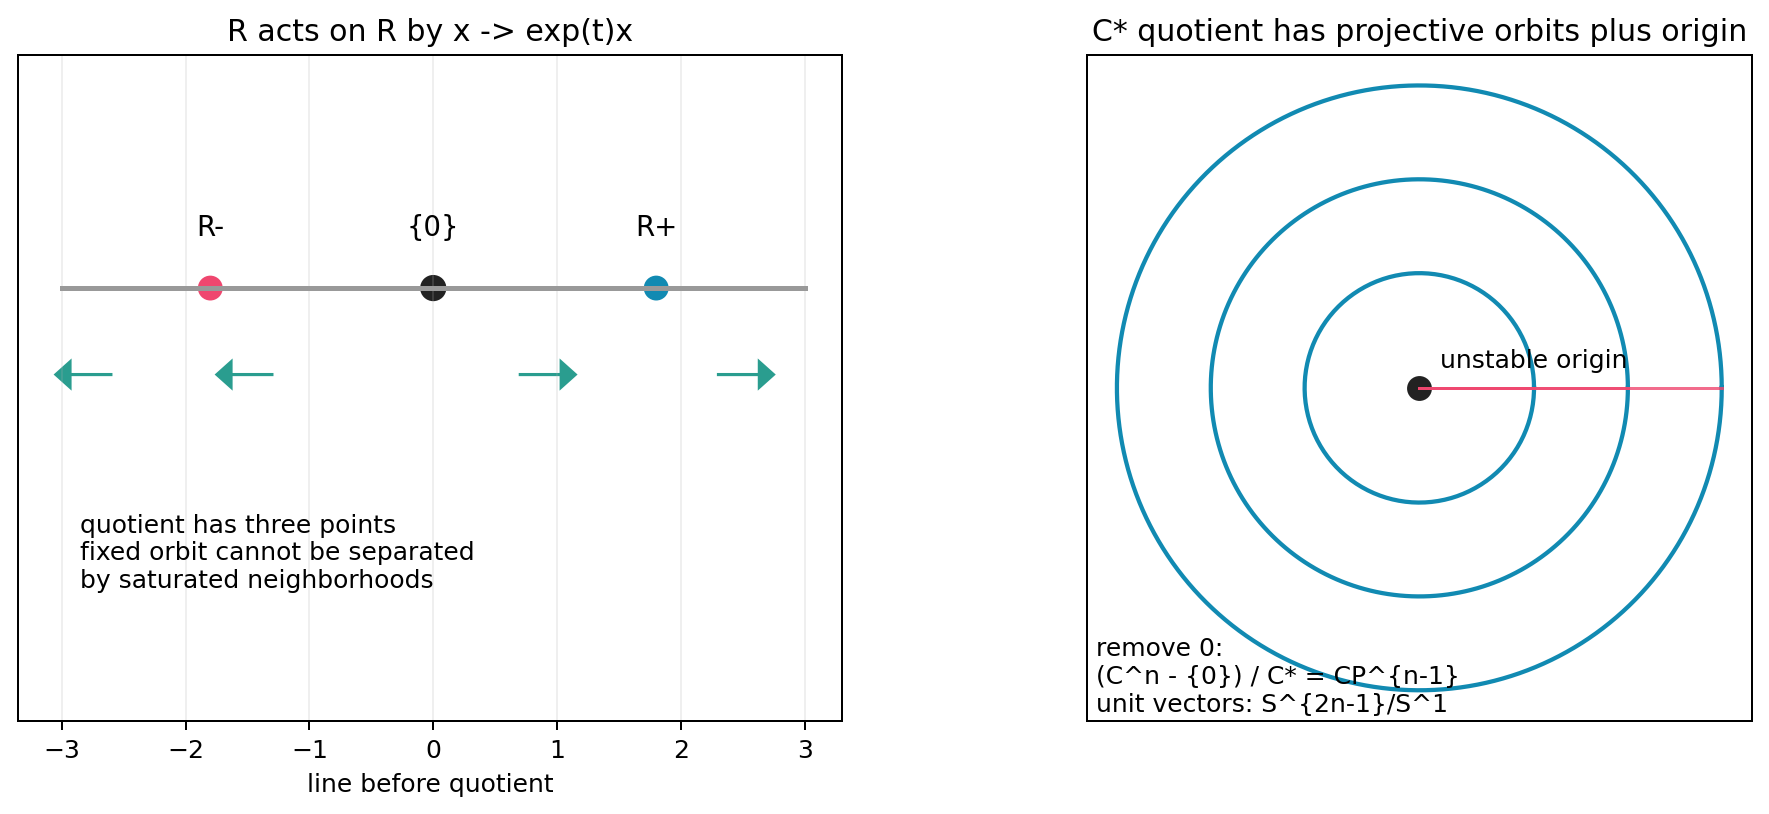

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

line = np.linspace(-3, 3, 400)
axes[0].plot(line, np.zeros_like(line), color="#999999", lw=2)
axes[0].scatter([-1.8, 0, 1.8], [0, 0, 0], color=["#ef476f", "#222222", "#118ab2"], s=[80, 90, 80])
axes[0].annotate("R-", (-1.8, 0.08), ha="center", fontsize=11)
axes[0].annotate("{0}", (0, 0.08), ha="center", fontsize=11)
axes[0].annotate("R+", (1.8, 0.08), ha="center", fontsize=11)
for start in [-2.6, -1.3, 0.7, 2.3]:
    direction = 0.45 if start > 0 else -0.45
    axes[0].arrow(start, -0.13, direction, 0, head_width=0.04, head_length=0.12, color="#2a9d8f", length_includes_head=True)
axes[0].text(-2.85, -0.45, "quotient has three points\nfixed orbit cannot be separated\nby saturated neighborhoods", fontsize=10)
axes[0].set_title("R acts on R by x -> exp(t)x")
axes[0].set_ylim(-0.65, 0.35)
axes[0].set_yticks([])
axes[0].set_xlabel("line before quotient")
axes[0].grid(True, axis="x", alpha=0.2)

theta = np.linspace(0, 2 * np.pi, 220)
for radius in [0.55, 1.0, 1.45]:
    axes[1].plot(radius * np.cos(theta), radius * np.sin(theta), color="#118ab2", lw=1.7)
    axes[1].plot([0, radius], [0, 0], color="#ef476f", lw=1.2, alpha=0.8)
axes[1].scatter([0], [0], color="#222222", s=80)
axes[1].text(0.1, 0.1, "unstable origin", fontsize=10)
axes[1].text(-1.55, -1.55, "remove 0:\n(C^n - {0}) / C* = CP^{n-1}\nunit vectors: S^{2n-1}/S^1", fontsize=10)
axes[1].set_aspect("equal")
axes[1].set_title("C* quotient has projective orbits plus origin")
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[1].grid(True, alpha=0.15)

orbit_space_checks = {
    "R_scaling_orbit_count": 3,
    "R_scaling_fixed_orbit_open_singleton": False,
    "Cstar_origin_removed_is_projective_model": True,
}
quotient_path = FIGURES / "orbit-space-quotient-pathologies.png"
fig.savefig(quotient_path, dpi=180, bbox_inches="tight")
plt.close(fig)

assert orbit_space_checks["R_scaling_orbit_count"] == 3
assert not orbit_space_checks["R_scaling_fixed_orbit_open_singleton"]
assert orbit_space_checks["Cstar_origin_removed_is_projective_model"]
show(relpath(quotient_path))

## Preview Of Reduction

For the diagonal `S^1` action on `C^n`, the source uses the standard symplectic form and the radial moment map `mu(z) = -|z|^2/2 + constant`. Choosing the constant `1/2` makes `mu^{-1}(0)` the unit sphere. The reduced space at zero is the quotient of that sphere by the phase action, `S^{2n-1}/S^1 = CP^{n-1}`.

The figure uses the radial coordinate as a faithful slice. The full level in `C^n` is higher-dimensional, but every orbit has the same radius, so the radial panel captures the moment image, the zero level, and the half-space image. The point is not that reduction is only radial; it is that the first example turns level set plus quotient into a concrete construction.

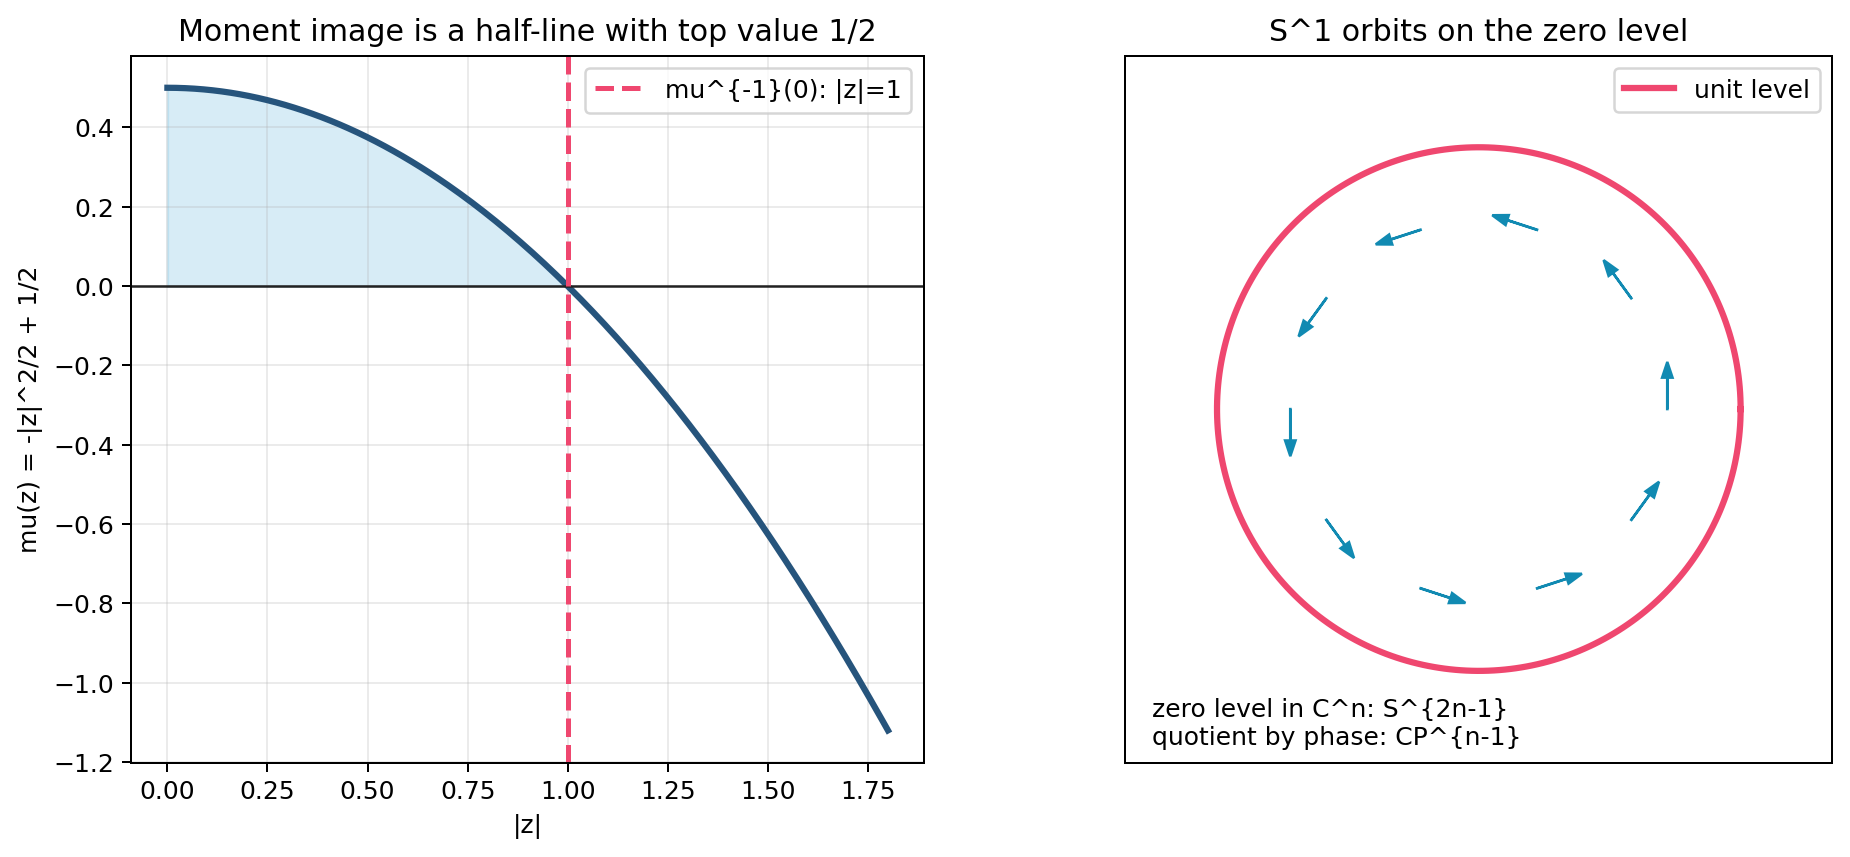

In [5]:
radius_values = np.linspace(0, 1.8, 240)
mu_values = -0.5 * radius_values**2 + 0.5
unit_samples = np.column_stack([np.cos(np.linspace(0, 2 * np.pi, 48)), np.sin(np.linspace(0, 2 * np.pi, 48))])
mu_unit_values = -0.5 * np.sum(unit_samples**2, axis=1) + 0.5
zero_level_residual = float(np.max(np.abs(mu_unit_values)))
moment_image_max = float(mu_values.max())

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.1))
axes[0].plot(radius_values, mu_values, color="#26547c", lw=2.5)
axes[0].axhline(0, color="#222222", lw=1)
axes[0].axvline(1, color="#ef476f", lw=2, linestyle="--", label="mu^{-1}(0): |z|=1")
axes[0].fill_between(radius_values, mu_values, 0, where=mu_values >= 0, color="#8ecae6", alpha=0.35)
axes[0].set_xlabel("|z|")
axes[0].set_ylabel("mu(z) = -|z|^2/2 + 1/2")
axes[0].set_title("Moment image is a half-line with top value 1/2")
axes[0].legend()
axes[0].grid(True, alpha=0.25)

circle = np.linspace(0, 2 * np.pi, 300)
axes[1].plot(np.cos(circle), np.sin(circle), color="#ef476f", lw=2.5, label="unit level")
for angle in np.linspace(0, 2 * np.pi, 10, endpoint=False):
    axes[1].arrow(0.72 * np.cos(angle), 0.72 * np.sin(angle), -0.18 * np.sin(angle), 0.18 * np.cos(angle), color="#118ab2", head_width=0.04, length_includes_head=True)
axes[1].text(-1.25, -1.28, "zero level in C^n: S^{2n-1}\nquotient by phase: CP^{n-1}", fontsize=10)
axes[1].set_aspect("equal")
axes[1].set_xlim(-1.35, 1.35)
axes[1].set_ylim(-1.35, 1.35)
axes[1].set_title("S^1 orbits on the zero level")
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[1].legend(loc="upper right")

reduction_path = FIGURES / "circle-action-cn-reduction-preview.png"
fig.savefig(reduction_path, dpi=180, bbox_inches="tight")
plt.close(fig)

assert zero_level_residual < 1e-12
assert abs(moment_image_max - 0.5) < 1e-12
show(relpath(reduction_path))

## Classical Momentum Maps

The source closes the lecture by naming the mechanical origin of "moment map." Translation symmetry gives linear momentum; rotational symmetry gives angular momentum. In coordinates on `R^6 = T*R^3`, write position `x` and covector/momentum `y`. The rotational moment map is `mu(x,y)=x cross y`. With the standard symplectic form, the generated vector field for an infinitesimal rotation `a` is `(a cross x, a cross y)`, and the Hamiltonian component is `<a, x cross y>`.

Sign conventions for cotangent coordinates and infinitesimal generators vary. The notebook records the convention it checks: angular momentum is tested against `d<a, x cross y> = i_{X_a} omega`, while the source-sign linear momentum `-y` is displayed as the translation convention used in the lecture.

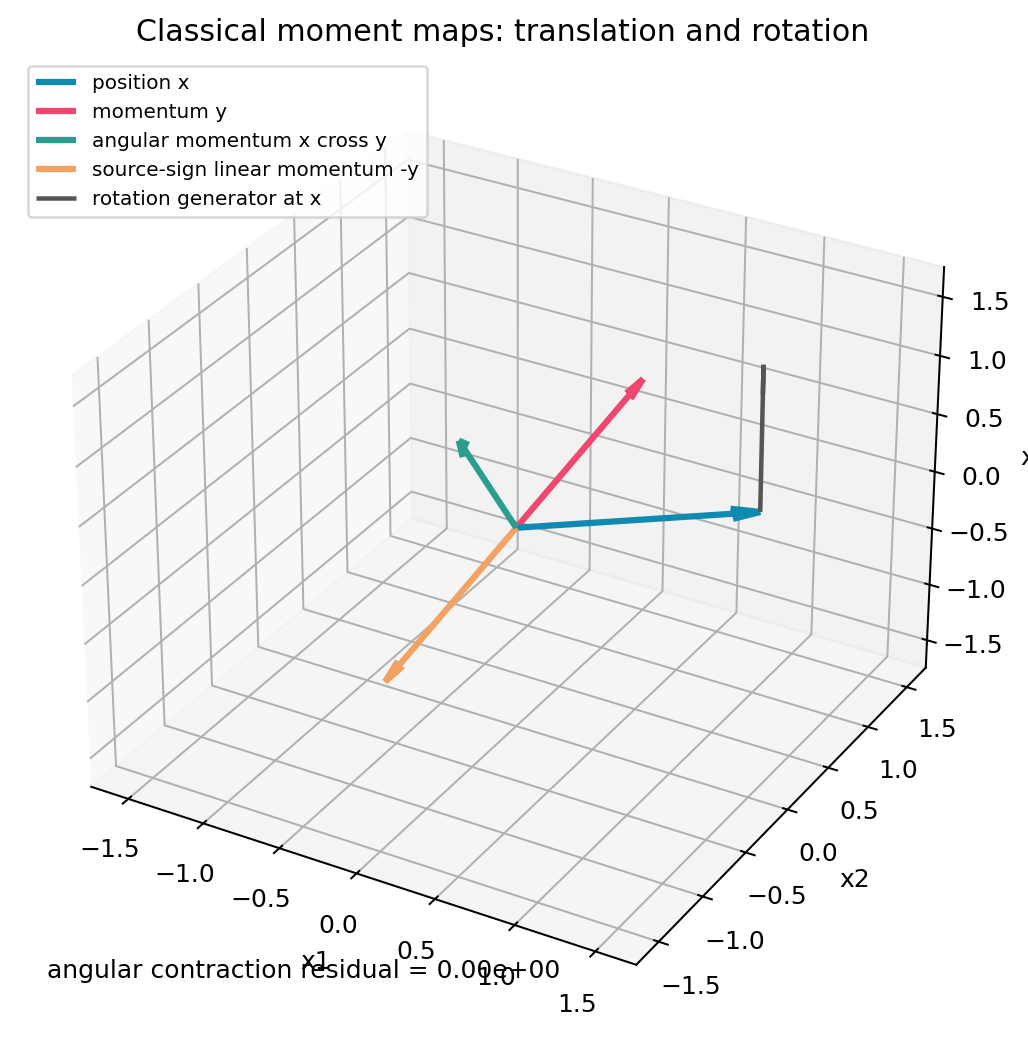

In [6]:
position = np.array([1.25, 0.55, 0.25])
momentum = np.array([0.2, 1.1, 0.65])
rotation_axis = np.array([0.35, -0.15, 0.92])
rotation_axis = rotation_axis / np.linalg.norm(rotation_axis)
angular_mu = np.cross(position, momentum)
linear_mu_source_sign = -momentum

Xx = np.cross(rotation_axis, position)
Xy = np.cross(rotation_axis, momentum)
dH_dx = np.cross(momentum, rotation_axis)
dH_dy = np.cross(rotation_axis, position)
iXomega_dx = -Xy
iXomega_dy = Xx
angular_contraction_residual = float(np.linalg.norm(dH_dx - iXomega_dx) + np.linalg.norm(dH_dy - iXomega_dy))

fig = plt.figure(figsize=(10.5, 7))
ax = fig.add_subplot(111, projection="3d")
origin = np.zeros(3)
vectors = [
    (position, "#118ab2", "position x"),
    (momentum, "#ef476f", "momentum y"),
    (angular_mu, "#2a9d8f", "angular momentum x cross y"),
    (linear_mu_source_sign, "#f4a261", "source-sign linear momentum -y"),
]
for vec, color, label in vectors:
    ax.quiver(*origin, *vec, color=color, linewidth=2.5, arrow_length_ratio=0.12, label=label)
ax.quiver(*position, *Xx, color="#555555", linewidth=1.8, arrow_length_ratio=0.18, label="rotation generator at x")
limit = 1.75
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.set_zlim(-limit, limit)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("x3")
ax.set_title("Classical moment maps: translation and rotation")
ax.text2D(0.03, 0.05, f"angular contraction residual = {angular_contraction_residual:.2e}", transform=ax.transAxes)
ax.legend(loc="upper left", fontsize=8)
classical_path = FIGURES / "linear-angular-momentum-maps.png"
fig.savefig(classical_path, dpi=180, bbox_inches="tight")
plt.close(fig)

assert angular_contraction_residual < 1e-12
show(relpath(classical_path))

## Coadjoint Orbits And Lie-Poisson Structure

For `SO(3)`, the Lie algebra and its dual can both be identified with `R^3`, and the adjoint/coadjoint actions are ordinary rotations. The coadjoint orbits are spheres centered at the origin. The homework asks the reader to show that each coadjoint orbit carries a canonical symplectic form. In this model, the form at `xi` is `omega_xi(a,b)=xi dot (a cross b)`. Its kernel in the whole Lie algebra is the stabilizer direction parallel to `xi`; on the tangent plane of the sphere, the form is nondegenerate.

This is the bridge to the next parts of the course: moment-map fibers, quotient spaces, coadjoint orbits, and convex moment images are all tied together by this same symplectic bookkeeping.

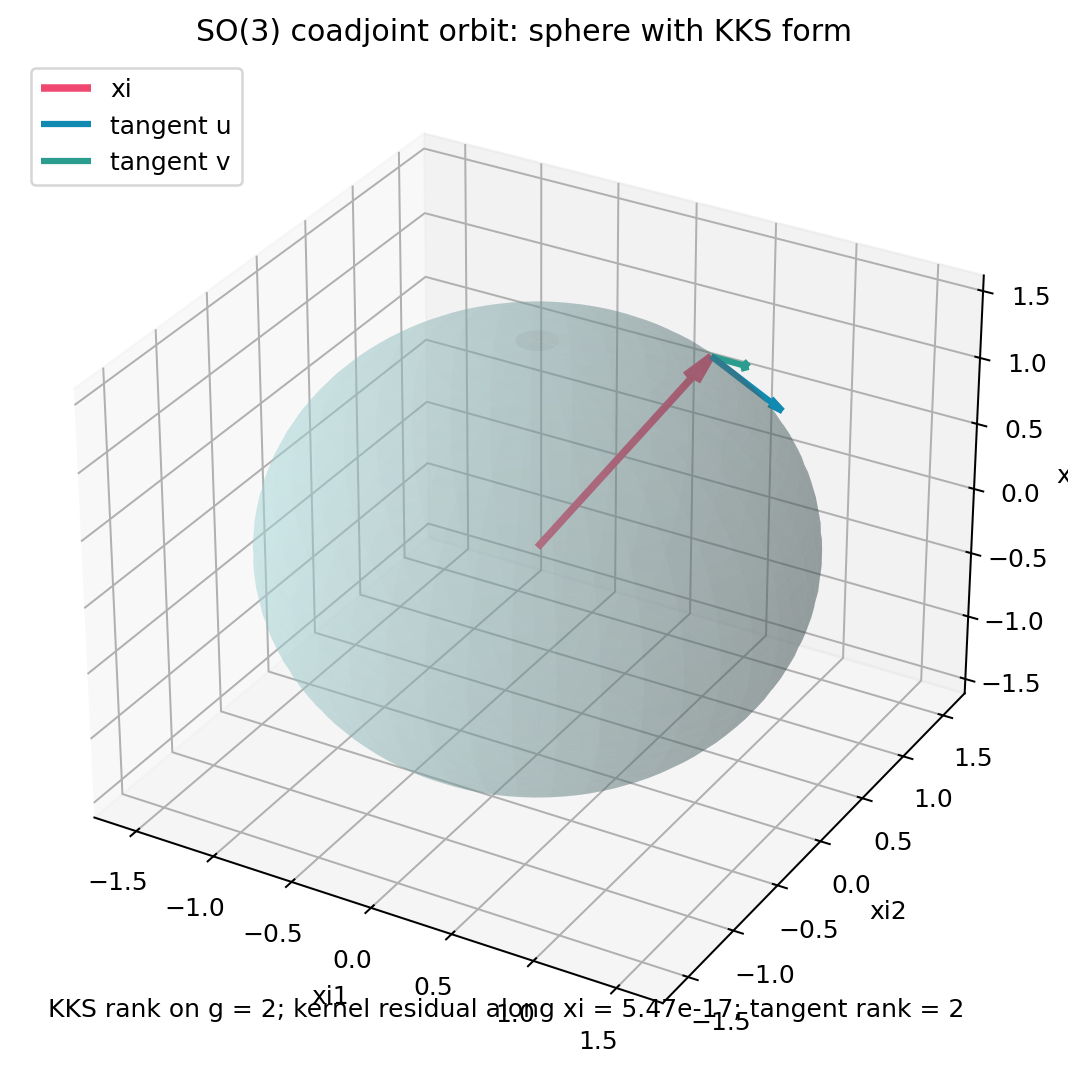

In [7]:
xi_vec = np.array([0.6, 0.85, 1.15])
xi_unit = xi_vec / np.linalg.norm(xi_vec)
cross_matrix = np.array(
    [
        [0, -xi_vec[2], xi_vec[1]],
        [xi_vec[2], 0, -xi_vec[0]],
        [-xi_vec[1], xi_vec[0], 0],
    ],
    dtype=float,
)
full_kks_rank = int(np.linalg.matrix_rank(cross_matrix, tol=1e-10))
kernel_residual = float(np.linalg.norm(cross_matrix @ xi_vec))

helper = np.array([1.0, 0.0, 0.0])
if abs(np.dot(helper, xi_unit)) > 0.9:
    helper = np.array([0.0, 1.0, 0.0])
tangent_u = helper - np.dot(helper, xi_unit) * xi_unit
tangent_u = tangent_u / np.linalg.norm(tangent_u)
tangent_v = np.cross(xi_unit, tangent_u)
tangent_form_matrix = np.array(
    [
        [np.dot(xi_vec, np.cross(tangent_u, tangent_u)), np.dot(xi_vec, np.cross(tangent_u, tangent_v))],
        [np.dot(xi_vec, np.cross(tangent_v, tangent_u)), np.dot(xi_vec, np.cross(tangent_v, tangent_v))],
    ]
)
tangent_rank = int(np.linalg.matrix_rank(tangent_form_matrix, tol=1e-10))

phi = np.linspace(0, np.pi, 42)
theta = np.linspace(0, 2 * np.pi, 84)
PHI, THETA = np.meshgrid(phi, theta)
r = np.linalg.norm(xi_vec)
SX = r * np.sin(PHI) * np.cos(THETA)
SY = r * np.sin(PHI) * np.sin(THETA)
SZ = r * np.cos(PHI)

fig = plt.figure(figsize=(10.5, 7.3))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(SX, SY, SZ, color="#a8dadc", alpha=0.3, linewidth=0)
ax.quiver(0, 0, 0, *xi_vec, color="#ef476f", linewidth=3, arrow_length_ratio=0.12, label="xi")
ax.quiver(*xi_vec, *(0.55 * tangent_u), color="#118ab2", linewidth=2.5, arrow_length_ratio=0.18, label="tangent u")
ax.quiver(*xi_vec, *(0.55 * tangent_v), color="#2a9d8f", linewidth=2.5, arrow_length_ratio=0.18, label="tangent v")
ax.set_title("SO(3) coadjoint orbit: sphere with KKS form")
ax.set_xlabel("xi1")
ax.set_ylabel("xi2")
ax.set_zlabel("xi3")
ax.text2D(0.03, 0.05, f"KKS rank on g = {full_kks_rank}; kernel residual along xi = {kernel_residual:.2e}; tangent rank = {tangent_rank}", transform=ax.transAxes)
ax.legend(loc="upper left")
coadjoint_path = FIGURES / "so3-coadjoint-orbit-kks-check.png"
fig.savefig(coadjoint_path, dpi=180, bbox_inches="tight")
plt.close(fig)

assert full_kks_rank == 2
assert kernel_residual < 1e-12
assert tangent_rank == 2
show(relpath(coadjoint_path))

## Final Sanity Ledger

The checks below are the executable coverage contract for this lecture. They verify the comoment/Lie-Poisson algebra, the quotient-space examples, the zero-level reduction preview, angular momentum as a Hamiltonian component, and the coadjoint-orbit symplectic form. Passing them does not prove every theorem in the lecture, but it validates that every major source concept has a faithful computational representative in the notebook.

In [8]:
results = {
    "lie_poisson_brackets": {"xy": str(bracket_xy), "yz": str(bracket_yz), "zx": str(bracket_zx)},
    "lie_poisson_jacobiator_zero": bool(jacobiator == 0),
    "R_scaling_orbit_count": orbit_space_checks["R_scaling_orbit_count"],
    "bad_fixed_orbit_topology_detected": not orbit_space_checks["R_scaling_fixed_orbit_open_singleton"],
    "circle_zero_level_residual": zero_level_residual,
    "moment_image_max": moment_image_max,
    "angular_contraction_residual": angular_contraction_residual,
    "so3_kks_full_rank": full_kks_rank,
    "so3_kks_kernel_residual": kernel_residual,
    "so3_kks_tangent_rank": tangent_rank,
}
save_json(CHECKS / "hamiltonian-actions-residuals.json", results)

final_sanity = {
    "passed": True,
    "artifacts": [
        relpath(FIGURES / "moment-comoment-definition-route.png"),
        relpath(FIGURES / "orbit-space-quotient-pathologies.png"),
        relpath(FIGURES / "circle-action-cn-reduction-preview.png"),
        relpath(FIGURES / "linear-angular-momentum-maps.png"),
        relpath(FIGURES / "so3-coadjoint-orbit-kks-check.png"),
        relpath(CHECKS / "source-span.json"),
        relpath(CHECKS / "visual-storyboard.json"),
        relpath(CHECKS / "hamiltonian-actions-residuals.json"),
    ],
    "assertions": results,
    "coverage_note": "Covers Lecture 22 sections 22.1-22.4 and Homework 17 themes without copying source prose.",
}
save_json(CHECKS / "final-sanity.json", final_sanity)

for relative_artifact in final_sanity["artifacts"]:
    candidate = BOOK_ROOT / relative_artifact
    assert candidate.exists(), relative_artifact
    assert candidate.stat().st_size > 0, relative_artifact

assert final_sanity["passed"]
assert results["lie_poisson_jacobiator_zero"]
assert results["R_scaling_orbit_count"] == 3
assert results["bad_fixed_orbit_topology_detected"]
assert results["circle_zero_level_residual"] < 1e-12
assert abs(results["moment_image_max"] - 0.5) < 1e-12
assert results["angular_contraction_residual"] < 1e-12
assert results["so3_kks_full_rank"] == 2
assert results["so3_kks_kernel_residual"] < 1e-12
assert results["so3_kks_tangent_rank"] == 2

print(json.dumps(final_sanity, indent=2))

{
  "passed": true,
  "artifacts": [
    "artifacts/lecture-22/figures/moment-comoment-definition-route.png",
    "artifacts/lecture-22/figures/orbit-space-quotient-pathologies.png",
    "artifacts/lecture-22/figures/circle-action-cn-reduction-preview.png",
    "artifacts/lecture-22/figures/linear-angular-momentum-maps.png",
    "artifacts/lecture-22/figures/so3-coadjoint-orbit-kks-check.png",
    "artifacts/lecture-22/checks/source-span.json",
    "artifacts/lecture-22/checks/visual-storyboard.json",
    "artifacts/lecture-22/checks/hamiltonian-actions-residuals.json"
  ],
  "assertions": {
    "lie_poisson_brackets": {
      "xy": "z",
      "yz": "x",
      "zx": "y"
    },
    "lie_poisson_jacobiator_zero": true,
    "R_scaling_orbit_count": 3,
    "bad_fixed_orbit_topology_detected": true,
    "circle_zero_level_residual": 1.1102230246251565e-16,
    "moment_image_max": 0.5,
    "angular_contraction_residual": 0.0,
    "so3_kks_full_rank": 2,
    "so3_kks_kernel_residual": 5.46946

## Takeaways And Exploration

A Hamiltonian action is more than a symplectic action: it comes with a moment map whose components generate the infinitesimal action. The comoment map is the same data viewed as a Lie algebra homomorphism into Poisson functions. Orbit spaces need topological care, and reduction works by imposing a moment-map level before quotienting by the symmetry. Classical linear and angular momentum are not analogies tacked on later; they are the model examples of the definition. Coadjoint orbits already carry the canonical symplectic structure that later reduction and convexity theorems will exploit.

For a short lab, change the constant in the radial circle-action moment map and predict the new reduced level. Then replace the `SO(3)` point `xi` by a scalar multiple and check how the KKS form scales on the tangent plane.